In [1]:
import pandas as pd

df = pd.read_csv("C:/Users/Admin/OneDrive/project01/emotion_dataset.csv")

df.head()

,text,label
0,I am very happy today,happy
1,I feel so sad,sad
2,This is making me angry,anger
3,I am scared,fear
4,I love this,joy


In [2]:
df = pd.read_csv("emotion_dataset.csv")

In [3]:
df.head()

,text,label
0,I am very happy today,happy
1,I feel so sad,sad
2,This is making me angry,anger
3,I am scared,fear
4,I love this,joy


In [4]:
import pandas as pd

df = pd.read_csv("emotion_dataset.csv")
df.head()

,text,label
0,I am very happy today,happy
1,I feel so sad,sad
2,This is making me angry,anger
3,I am scared,fear
4,I love this,joy


In [5]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['cleaned_text'] = df['text'].apply(clean_text)

df[['text','cleaned_text']]

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,text,cleaned_text
0,I am very happy today,happy today
1,I feel so sad,feel sad
2,This is making me angry,making angry
3,I am scared,scared
4,I love this,love


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['cleaned_text'])
y = df['label']

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [8]:
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.0


In [10]:
sample = ["I am very sad"]
sample_clean = [clean_text(sample[0])]
sample_vec = vectorizer.transform(sample_clean)

print("Prediction:", model.predict(sample_vec))

Prediction: ['sad']


In [11]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[0 0]
 [1 0]]
              precision    recall  f1-score   support

        fear       0.00      0.00      0.00       0.0
         joy       0.00      0.00      0.00       1.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0



C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Admin\anaconda3\Lib\site-packages\sklea

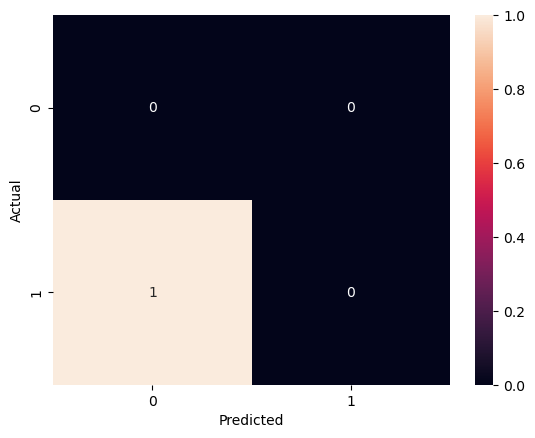

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [13]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

print("Naive Bayes Accuracy:", nb_model.score(X_test, y_test))

Naive Bayes Accuracy: 0.0


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)